# Подготовка данных

## Импорты

In [1]:
import numpy as np
import pandas as pd
from src.signal_processing.preprocessing import calc_base_signal_components
import matplotlib.pyplot as plt

## Загрузка данных

In [2]:
# Файл `Run200_Wave_0_1.txt` скачан по ссылке https://www.kaggle.com/competitions/signal-types-classification/data
dataset = pd.read_csv('../data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

## Подготовка данных

In [3]:
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(dataset.shape[1]))
adc_inversion_term = 2 ** 14
df_inverted = (adc_inversion_term - dataset)
min_vals = df_inverted.apply(min, axis=1)
df_raw = df_inverted.sub(min_vals, axis=0)
assert df_raw.min().min() == 0
assert df_raw.shape[0] == dataset.shape[0]
df = pd.DataFrame({'data_array': df_raw.apply(lambda row: np.array(row.values), axis=1)})

## Построение базовых компонентов сигнала

In [4]:
signal_df = (df.pipe(lambda _df: calc_base_signal_components(_df, signal_level_threshold_at_end=0.10)))

In [5]:
signal_df.head()

,data_array,signal_start,signal_end,signal_indices_in_data_array,signal_array,signal_own_indices,peak_idx,peak_idx_in_signal,amplitude,signal_area,signal_duration
0,"[10, 7, 6, 8, 12, 10, 6, 8, 10, 10, 10, 8, 6, ...",140,179,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[12, 7, 12, 12, 10, 16, 67, 267, 452, 539, 452...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",149,9,539,4028.0,40
1,"[8, 6, 8, 2, 4, 6, 8, 6, 5, 7, 5, 5, 6, 4, 1, ...",140,177,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[8, 8, 4, 5, 9, 9, 16, 155, 648, 1393, 1907, 1...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",150,10,1907,11692.5,38
2,"[10, 10, 8, 5, 10, 6, 6, 11, 7, 6, 7, 7, 7, 6,...",140,177,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[12, 5, 2, 11, 18, 20, 48, 272, 943, 1889, 249...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",151,11,2566,16297.0,38
3,"[3, 9, 13, 7, 7, 9, 11, 9, 7, 11, 11, 7, 5, 10...",140,178,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[11, 4, 12, 15, 11, 7, 51, 201, 404, 573, 534,...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",149,9,573,4271.0,39
4,"[5, 13, 5, 7, 1, 8, 5, 4, 12, 7, 6, 3, 6, 5, 8...",140,178,"[140, 141, 142, 143, 144, 145, 146, 147, 148, ...","[5, 6, 8, 8, 4, 14, 38, 197, 824, 1532, 1800, ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",150,10,1800,11386.5,39


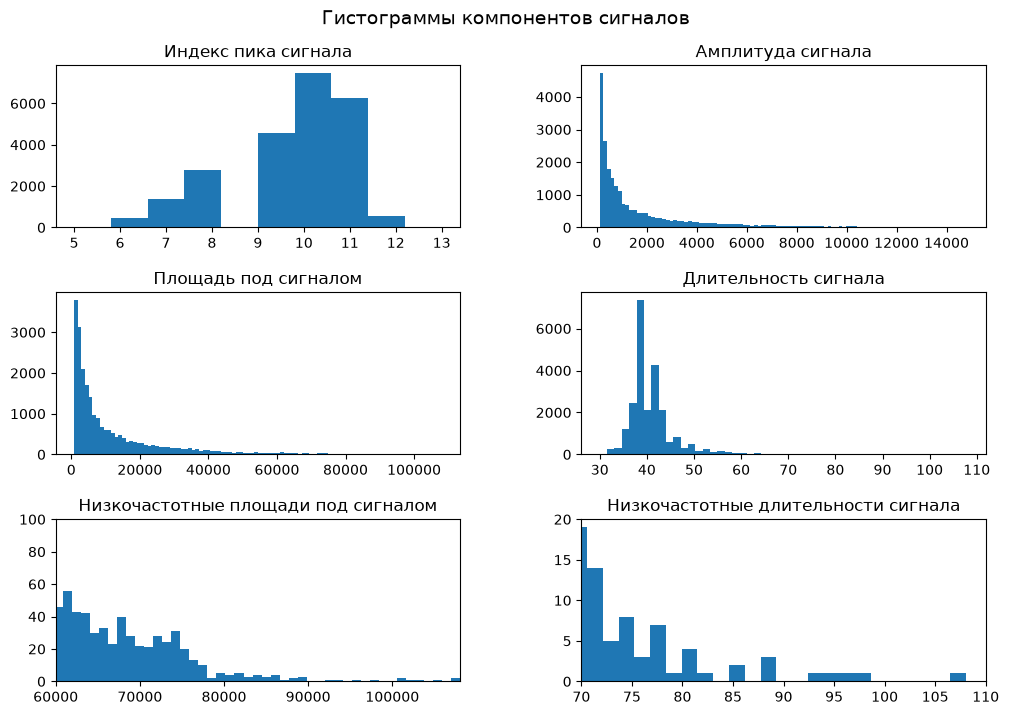

In [49]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), gridspec_kw={'wspace': 0.3, 'hspace': 0.4})
fig.suptitle("Гистограммы компонентов сигналов", fontsize=14, y=0.95)
axes[0][0].hist(signal_df['peak_idx_in_signal'], bins=10)
axes[0][0].set_title("Индекс пика сигнала")
axes[0][1].hist(signal_df['amplitude'], bins=100)
axes[0][1].set_title("Амплитуда сигнала")
axes[1][0].hist(signal_df['signal_area'], bins=100)
axes[1][0].set_title("Площадь под сигналом")
axes[1][1].hist(signal_df['signal_duration'], bins=50)
axes[1][1].set_title("Длительность сигнала")
axes[2][0].hist(signal_df['signal_area'], bins=100)
axes[2][0].set_title("Низкочастотные площади под сигналом")
axes[2][1].hist(signal_df['signal_duration'], bins=50)
axes[2][1].set_title("Низкочастотные длительности сигнала")
axes[2][0].set_xlim(60000, signal_df['signal_area'].max())
axes[2][0].set_ylim(0, 100)
axes[2][1].set_xlim(70, 110)
axes[2][1].set_ylim(0, 20)
plt.show()

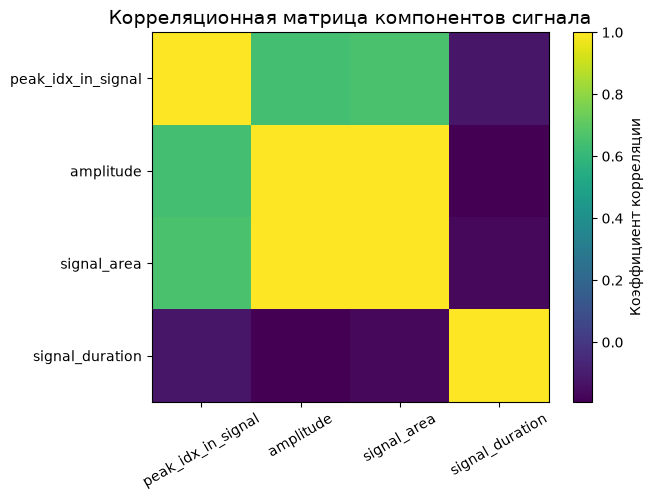

In [48]:
components = ['peak_idx_in_signal', 'amplitude', 'signal_area', 'signal_duration']
plt.imshow(signal_df[['peak_idx_in_signal', 'amplitude', 'signal_area', 'signal_duration']].corr(), aspect='auto')
plt.colorbar(label='Коэффициент корреляции')
plt.xticks(range(len(components)), components, rotation=30)
plt.yticks(range(len(components)), components)
plt.title('Корреляционная матрица компонентов сигнала', fontsize=14)
plt.show()

## Сохранение данных

In [7]:
df.to_parquet("../data/Run200_Wave_0_1_base_features.parquet")